# E-com user behaviour 

This dataset captures detailed behavioral and demographic information of users interacting with an e-commerce platform. It includes key metrics such as user engagement (time spent on site, pages viewed, session duration), purchasing behavior (cart items, previous purchases, conversion), and marketing interactions (advertisement clicks, discount exposure).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv('ecommerce_user_behavior.csv')
display(df.head(5))

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0


In [3]:
df = df.drop(columns=['user_id']) 
# df.drop(columns = ['user_id'] , inplace = True)

In [4]:
print(df.info())
print("-"*45)
print(df.shape)
print("-"*45)
print(df.duplicated().sum())
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 7840 non-null   float64
 1   gender              7840 non-null   object 
 2   device_type         7840 non-null   object 
 3   time_on_site        7840 non-null   float64
 4   pages_viewed        7840 non-null   float64
 5   previous_purchases  7840 non-null   float64
 6   cart_items          7840 non-null   float64
 7   discount_seen       7840 non-null   float64
 8   ad_clicked          7840 non-null   float64
 9   returning_user      7840 non-null   float64
 10  avg_session_time    7840 non-null   float64
 11  bounce_rate         7840 non-null   float64
 12  purchase            7840 non-null   float64
dtypes: float64(11), object(2)
memory usage: 812.6+ KB
None
---------------------------------------------
(8000, 13)
-----------------------------------------

age                   160
gender                160
device_type           160
time_on_site          160
pages_viewed          160
previous_purchases    160
cart_items            160
discount_seen         160
ad_clicked            160
returning_user        160
avg_session_time      160
bounce_rate           160
purchase              160
dtype: int64

In [5]:
# Fill nulls with mode (for categorical)
# Fill nulls with median (more robust for outliers)
for col in df.columns:
    if df[col].dtype == 'object':
       df[col] =  df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [6]:
df.isnull().sum()

age                   0
gender                0
device_type           0
time_on_site          0
pages_viewed          0
previous_purchases    0
cart_items            0
discount_seen         0
ad_clicked            0
returning_user        0
avg_session_time      0
bounce_rate           0
purchase              0
dtype: int64

In [7]:
# Remove leading/trailing whitespace from string columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

df.head(10)

,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,1.0,0.0,6.97,28.18,1.0
1,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,32.0,Female,Mobile,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,14.30,79.03,1.0
4,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0
5,56.0,Female,Desktop,26.60,1.0,12.0,7.0,1.0,1.0,0.0,28.40,13.90,1.0
6,36.0,Male,Mobile,7.60,11.0,11.0,6.0,1.0,1.0,1.0,4.51,13.12,1.0
7,40.0,Female,Mobile,26.98,7.0,5.0,2.0,1.0,0.0,0.0,33.34,12.61,1.0
8,28.0,Female,Mobile,10.90,14.0,7.0,9.0,0.0,0.0,1.0,13.80,85.46,1.0
9,28.0,Female,Mobile,9.97,3.0,14.0,8.0,0.0,0.0,0.0,14.12,14.16,1.0


In [8]:
df.describe(include='object')

,gender,device_type
count,8000,8000
unique,2,3
top,Male,Mobile
freq,4091,4845


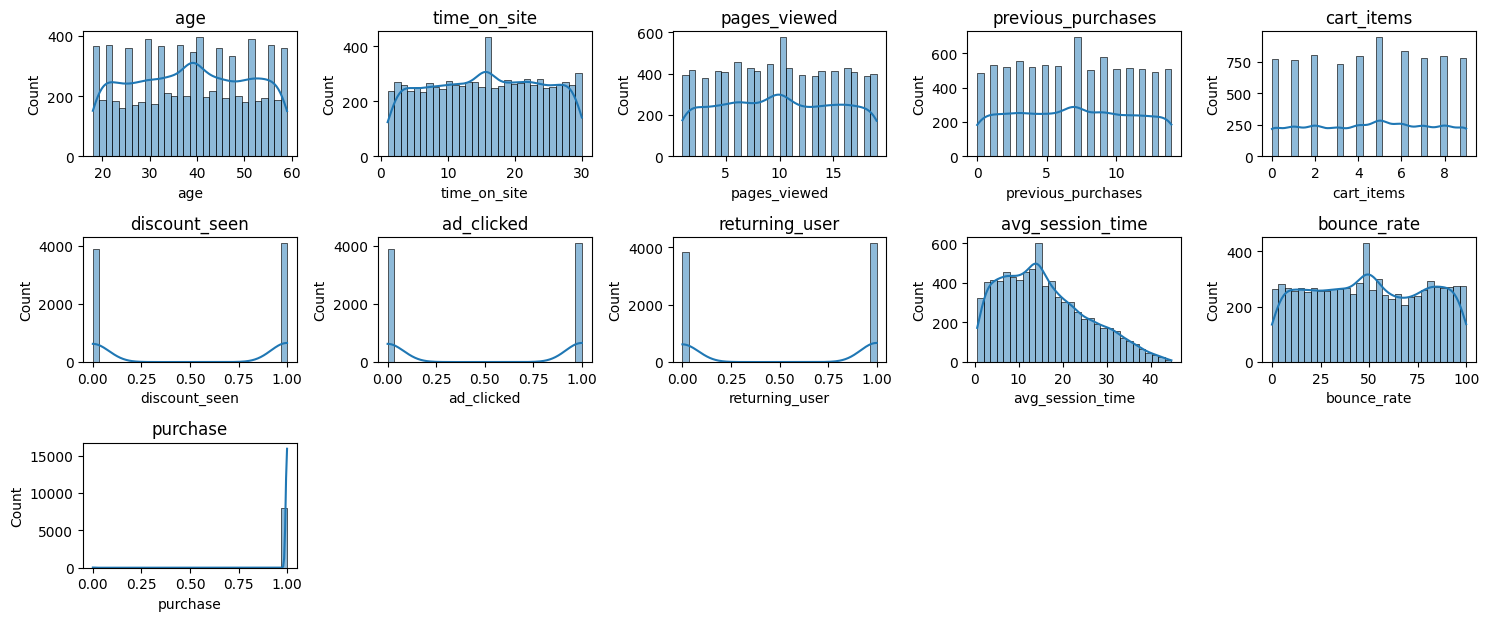

In [9]:
# distribution plot for numerical columns
import seaborn as sns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(5, 5, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

In [9]:
df.to_csv('clean_data.csv' , index=False)